In [ ]:
from google.colab import files
uploaded = files.upload()
# Upload archive__11_.zip

Saving archive (11).zip to archive (11).zip


In [ ]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

with zipfile.ZipFile('archive (11).zip', 'r') as z:
    z.extractall('.')

df = pd.read_csv('WineQT.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

Shape: (1143, 13)

First 5 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1

In [ ]:
print("=== Basic Statistics ===")
print(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Wine Quality Distribution ===")
print(df['quality'].value_counts().sort_index())

print("\nQuality range:", df['quality'].min(), "to", df['quality'].max())

=== Basic Statistics ===
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000     

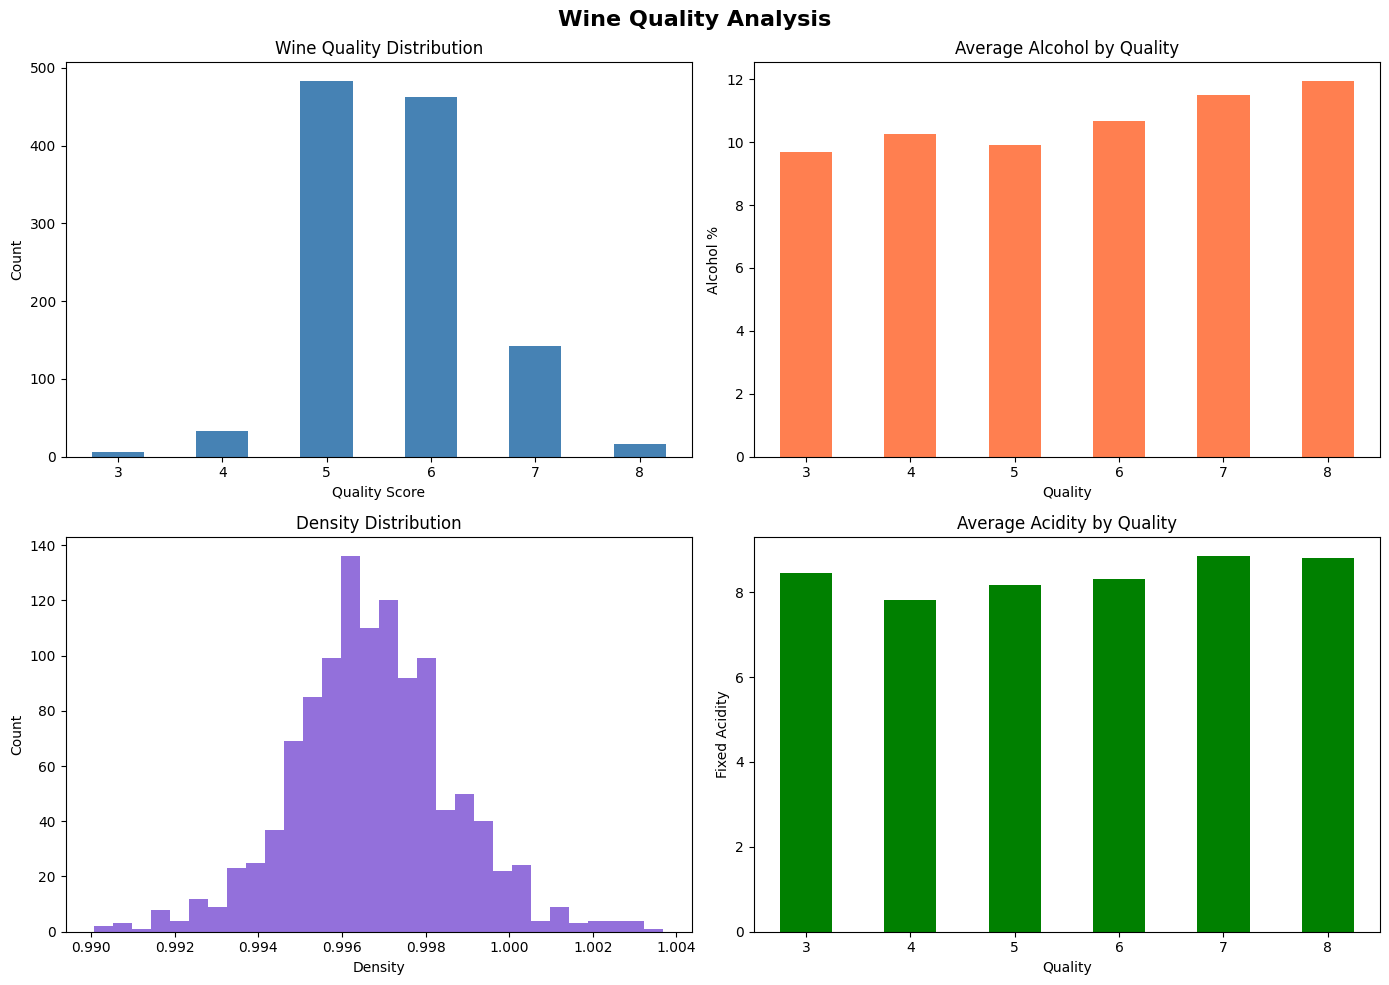

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 - Quality distribution
df['quality'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Wine Quality Distribution')
axes[0,0].set_xlabel('Quality Score')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

# Chart 2 - Alcohol vs Quality
df.groupby('quality')['alcohol'].mean().plot(
    kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Average Alcohol by Quality')
axes[0,1].set_xlabel('Quality')
axes[0,1].set_ylabel('Alcohol %')
axes[0,1].tick_params(axis='x', rotation=0)

# Chart 3 - Density distribution
axes[1,0].hist(df['density'], bins=30, color='mediumpurple')
axes[1,0].set_title('Density Distribution')
axes[1,0].set_xlabel('Density')
axes[1,0].set_ylabel('Count')

# Chart 4 - Acidity vs Quality
df.groupby('quality')['fixed acidity'].mean().plot(
    kind='bar', ax=axes[1,1], color='green')
axes[1,1].set_title('Average Acidity by Quality')
axes[1,1].set_xlabel('Quality')
axes[1,1].set_ylabel('Fixed Acidity')
axes[1,1].tick_params(axis='x', rotation=0)

plt.suptitle('Wine Quality Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

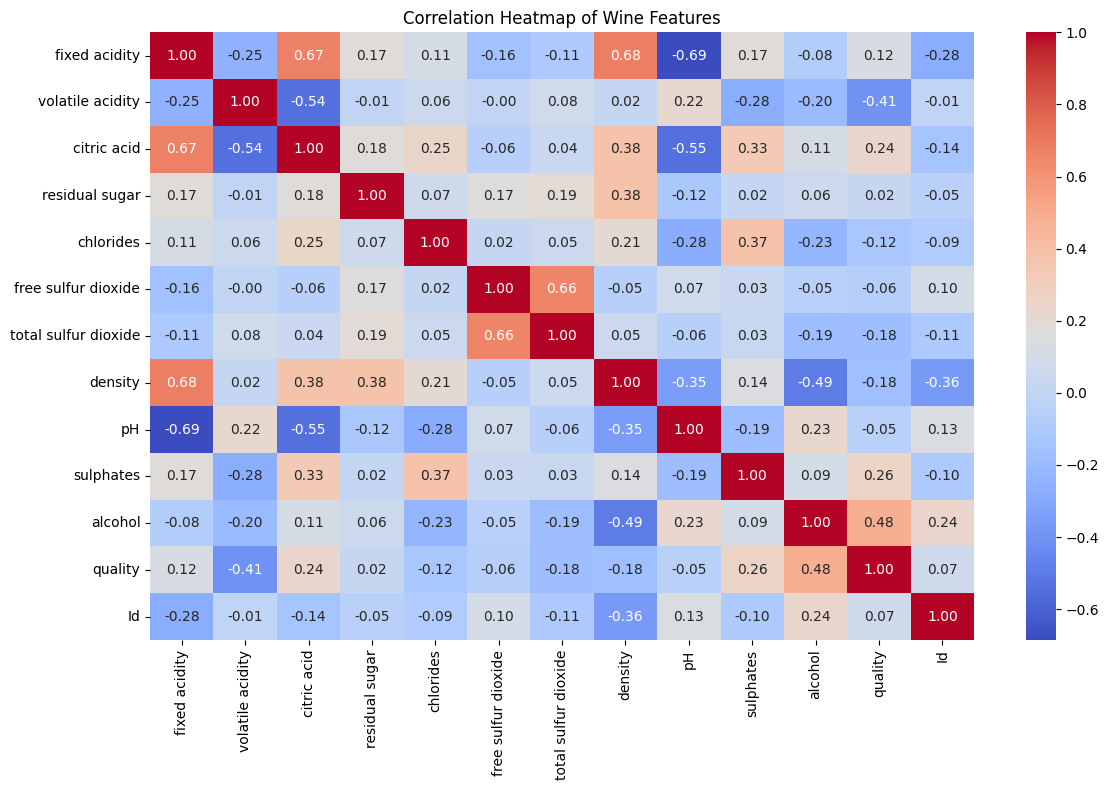

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Wine Features')
plt.tight_layout()
plt.show()

In [ ]:
# Drop Id column - not needed
df = df.drop('Id', axis=1, errors='ignore')

# Create binary quality label
# Good wine = quality >= 7, Bad wine = quality < 7
df['quality_label'] = df['quality'].apply(
    lambda x: 'Good' if x >= 7 else 'Bad')

print("Quality label distribution:")
print(df['quality_label'].value_counts())

# Features and target
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality']

print("\nFeatures:", X.columns.tolist())
print("X shape:", X.shape)

Quality label distribution:
quality_label
Bad     984
Good    159
Name: count, dtype: int64

Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
X shape: (1143, 11)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData scaled and ready! ✅")

Training size: 914
Testing size: 229

Data scaled and ready! ✅


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("=== RANDOM FOREST ===")
print(f"Accuracy: {acc_rf*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST ===
Accuracy: 69.87%

Classification Report:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.71      0.80      0.75        96
           6       0.68      0.66      0.67        99
           7       0.72      0.69      0.71        26
           8       0.00      0.00      0.00         2

    accuracy                           0.70       229
   macro avg       0.42      0.43      0.43       229
weighted avg       0.67      0.70      0.68       229



In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(random_state=42, max_iter=1000)
sgd_model.fit(X_train_scaled, y_train)
y_pred_sgd = sgd_model.predict(X_test_scaled)
acc_sgd = accuracy_score(y_test, y_pred_sgd)

print("=== STOCHASTIC GRADIENT DESCENT ===")
print(f"Accuracy: {acc_sgd*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_sgd))

=== STOCHASTIC GRADIENT DESCENT ===
Accuracy: 50.22%

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         6
           5       0.57      0.80      0.67        96
           6       0.53      0.24      0.33        99
           7       0.30      0.54      0.39        26
           8       0.00      0.00      0.00         2

    accuracy                           0.50       229
   macro avg       0.24      0.26      0.23       229
weighted avg       0.51      0.50      0.47       229



In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("=== SUPPORT VECTOR MACHINE ===")
print(f"Accuracy: {acc_svm*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

=== SUPPORT VECTOR MACHINE ===
Accuracy: 63.76%

Classification Report:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.70      0.74      0.72        96
           6       0.59      0.69      0.64        99
           7       0.54      0.27      0.36        26
           8       0.00      0.00      0.00         2

    accuracy                           0.64       229
   macro avg       0.37      0.34      0.34       229
weighted avg       0.61      0.64      0.62       229



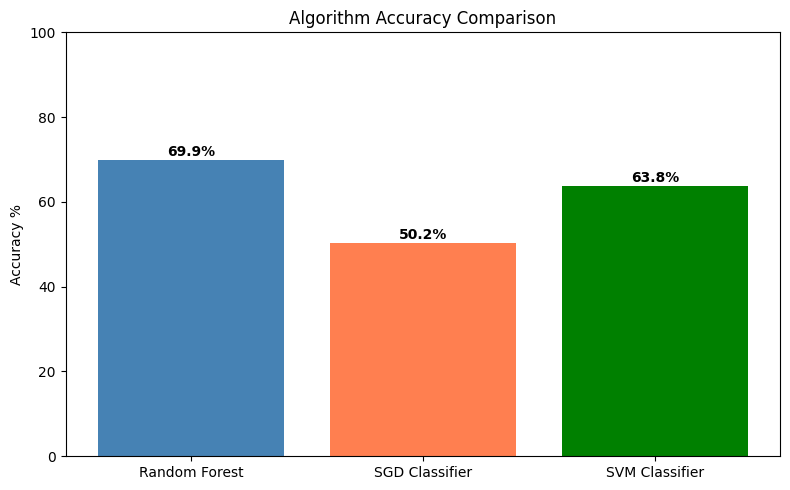


Best Model: Random Forest with 69.87% accuracy


In [ ]:
models = {
    'Random Forest': acc_rf * 100,
    'SGD Classifier': acc_sgd * 100,
    'SVM Classifier': acc_svm * 100
}

plt.figure(figsize=(8, 5))
colors = ['steelblue', 'coral', 'green']
bars = plt.bar(models.keys(), models.values(), color=colors)
plt.title('Algorithm Accuracy Comparison')
plt.ylabel('Accuracy %')
plt.ylim(0, 100)
for bar, val in zip(bars, models.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 1, f'{val:.1f}%',
             ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

best_model = max(models, key=models.get)
print(f"\nBest Model: {best_model} with {models[best_model]:.2f}% accuracy")

=== FEATURE IMPORTANCE (Random Forest) ===
                 Feature  Importance
10               alcohol    0.146276
9              sulphates    0.119159
1       volatile acidity    0.110288
6   total sulfur dioxide    0.101212
7                density    0.090431
4              chlorides    0.082482
0          fixed acidity    0.073160
2            citric acid    0.072021
8                     pH    0.070924
5    free sulfur dioxide    0.068906
3         residual sugar    0.065142


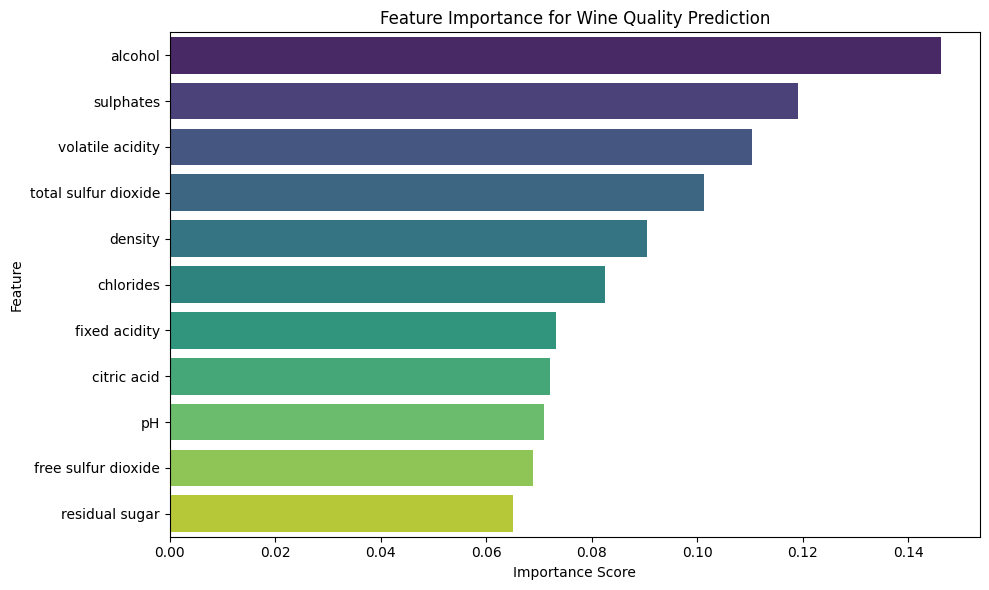

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("=== FEATURE IMPORTANCE (Random Forest) ===")
print(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature',
            data=feature_importance, palette='viridis',
            hue='Feature', legend=False)
plt.title('Feature Importance for Wine Quality Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
def predict_wine_quality(fixed_acidity, volatile_acidity, citric_acid,
                          residual_sugar, chlorides, free_sulfur_dioxide,
                          total_sulfur_dioxide, density, pH,
                          sulphates, alcohol):

    input_data = np.array([[fixed_acidity, volatile_acidity, citric_acid,
                            residual_sugar, chlorides, free_sulfur_dioxide,
                            total_sulfur_dioxide, density, pH,
                            sulphates, alcohol]])
    input_scaled = scaler.transform(input_data)
    prediction = rf_model.predict(input_scaled)[0]
    label = 'Good 🍷' if prediction >= 7 else 'Average/Bad 😐'
    return prediction, label

print("=== WINE QUALITY PREDICTIONS ===\n")

# High quality wine
q1, l1 = predict_wine_quality(7.4, 0.39, 0.33, 2.4, 0.034,
                               19.0, 32.0, 0.9934, 3.46, 0.72, 12.4)
print(f"Wine 1 → Quality: {q1} → {l1}")

# Low quality wine
q2, l2 = predict_wine_quality(8.1, 0.92, 0.0, 1.8, 0.105,
                               20.0, 84.0, 0.9975, 3.44, 0.49, 9.2)
print(f"Wine 2 → Quality: {q2} → {l2}")

=== WINE QUALITY PREDICTIONS ===

Wine 1 → Quality: 6 → Average/Bad 😐
Wine 2 → Quality: 5 → Average/Bad 😐


In [ ]:
print("=== WINE QUALITY PREDICTION SUMMARY ===\n")
print(f"Dataset: {df.shape[0]} wine samples analyzed")
print(f"Features used: {X.shape[1]} chemical properties")
print(f"\nModel Accuracies:")
for name, acc in models.items():
    print(f"  {name}: {acc:.2f}%")
print(f"\nBest Model: {best_model} ({models[best_model]:.2f}%)")
print(f"\nTop 3 Important Features:")
for _, row in feature_importance.head(3).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")
print("\nSteps Completed:")
print("  ✅ Data Exploration and Visualization")
print("  ✅ Feature Engineering")
print("  ✅ Random Forest Classifier")
print("  ✅ SGD Classifier")
print("  ✅ SVM Classifier")
print("  ✅ Algorithm Comparison")
print("  ✅ Feature Importance Analysis")
print("\nWine quality successfully predicted using ML! 🍷")

=== WINE QUALITY PREDICTION SUMMARY ===

Dataset: 1143 wine samples analyzed
Features used: 11 chemical properties

Model Accuracies:
  Random Forest: 69.87%
  SGD Classifier: 50.22%
  SVM Classifier: 63.76%

Best Model: Random Forest (69.87%)

Top 3 Important Features:
  alcohol: 0.1463
  sulphates: 0.1192
  volatile acidity: 0.1103

Steps Completed:
  ✅ Data Exploration and Visualization
  ✅ Feature Engineering
  ✅ Random Forest Classifier
  ✅ SGD Classifier
  ✅ SVM Classifier
  ✅ Algorithm Comparison
  ✅ Feature Importance Analysis

Wine quality successfully predicted using ML! 🍷
